<a href="https://colab.research.google.com/github/GeorgeT27/Generative-model-DYI/blob/main/Copy_of_Conditional_Flow_Matching_Morpho_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Compose, Normalize
from torch.utils.data import DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import StepLR
import torch.distributions as distributions
from tqdm import tqdm
import pandas as pd
from copy import deepcopy
import os
import sys
sys.path.append('/workspace/Generative-model-DYI/Morpho-MNIST/')
from morphomnist import io

In [2]:
class RectifiedFlow:
  def euler(self,x_t,v,dt):
    x_t=x_t+v*dt
    return x_t
  def create_flow(self,x_1,t):
    x_0=torch.randn_like(x_1)
    t=t[:,None,None,None]
    x_t=t*x_1+(1-t)*x_0
    return x_t,x_0
  def mse_loss(self,x_1,x_0,v):
    loss=F.mse_loss(x_1-x_0,v)
    return loss

In [3]:
# Replace your existing FiLM model with this improved deep version

class ImprovedFiLMLayer(nn.Module):
    """Better FiLM layer with proper initialization and optional bypass"""
    def __init__(self, num_features, condition_dim, use_film=True):
        super().__init__()
        self.use_film = use_film
        
        if use_film:
            self.scale_transform = nn.Linear(condition_dim, num_features)
            self.shift_transform = nn.Linear(condition_dim, num_features)
            
            # Better initialization - start closer to identity
            nn.init.zeros_(self.scale_transform.weight)
            nn.init.zeros_(self.scale_transform.bias)
            nn.init.zeros_(self.shift_transform.weight)
            nn.init.zeros_(self.shift_transform.bias)
    
    def forward(self, x, condition):
        if not self.use_film or condition is None:
            return x
            
        scale = self.scale_transform(condition).unsqueeze(-1).unsqueeze(-1)
        shift = self.shift_transform(condition).unsqueeze(-1).unsqueeze(-1)
        
        # Apply FiLM: x * (1 + scale) + shift (more stable than x * scale + shift)
        return x * (1 + scale) + shift

class DeepResBlockFiLM(nn.Module):
    """Deep residual block with FiLM conditioning"""
    
    def __init__(self, in_channels, out_channels, condition_dim, use_film=True, dropout=0.1):
        super().__init__()
        
        # First conv path
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_channels), out_channels)
        self.film1 = ImprovedFiLMLayer(out_channels, condition_dim, use_film)
        
        # Second conv path
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(8, out_channels), out_channels)
        self.film2 = ImprovedFiLMLayer(out_channels, condition_dim, use_film)
        
        # Dropout for regularization
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        
        # Shortcut connection
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        
        self.act = nn.SiLU()  # Better activation than ReLU
    
    def forward(self, x, condition=None):
        residual = self.shortcut(x)
        
        # First conv block
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.film1(h, condition)
        h = self.act(h)
        h = self.dropout(h)
        
        # Second conv block
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.film2(h, condition)
        
        # Residual connection
        return self.act(h + residual)

class AttentionBlock(nn.Module):
    """Self-attention block for better feature processing"""
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.norm = nn.GroupNorm(min(8, channels), channels)
        self.q = nn.Conv2d(channels, channels, 1)
        self.k = nn.Conv2d(channels, channels, 1)
        self.v = nn.Conv2d(channels, channels, 1)
        self.proj_out = nn.Conv2d(channels, channels, 1)
        
    def forward(self, x):
        h_ = self.norm(x)
        q = self.q(h_)
        k = self.k(h_)
        v = self.v(h_)
        
        # Compute attention
        b, c, h, w = q.shape
        q = q.reshape(b, c, h * w).transpose(1, 2)
        k = k.reshape(b, c, h * w)
        v = v.reshape(b, c, h * w).transpose(1, 2)
        
        attn = torch.bmm(q, k) * (c ** -0.5)
        attn = F.softmax(attn, dim=-1)
        
        h_ = torch.bmm(attn, v).transpose(1, 2).reshape(b, c, h, w)
        h_ = self.proj_out(h_)
        
        return x + h_

In [ ]:
class DeepMiniUnetFiLM(nn.Module):
    """Deep U-Net with FiLM conditioning - Fixed channel dimensions"""
    
    def __init__(self, base_channels=64, condition_dim=128, use_morphometrics=False, 
                 num_res_blocks=2, use_attention=True, dropout=0.1):
        super().__init__()
        
        self.condition_dim = condition_dim
        self.base_channels = base_channels
        self.use_morphometrics = use_morphometrics
        self.use_attention = use_attention
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(base_channels, condition_dim),
            nn.SiLU(),
            nn.Linear(condition_dim, condition_dim),
        )
        
        # Label embedding
        self.label_embed = nn.Embedding(11, condition_dim)  # 0-9 + unconditional
        
        # Morphometric embedding (only if needed)
        if use_morphometrics:
            self.morpho_net = nn.Sequential(
                nn.Linear(3, condition_dim // 2),  # area, thickness, length
                nn.SiLU(),
                nn.Linear(condition_dim // 2, condition_dim),
                nn.SiLU(),
                nn.Linear(condition_dim, condition_dim)
            )
        
        # Input layer
        self.conv_in = nn.Conv2d(1, base_channels, 3, padding=1)
        
        # Channel progression: 64 -> 128 -> 256 -> 512
        ch = [base_channels, base_channels*2, base_channels*4, base_channels*8]
        
        # ENCODER
        self.down_blocks = nn.ModuleList()
        
        # Level 1: 64 -> 128 (28x28)
        level1_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[0] if i == 0 else ch[1]
            level1_blocks.append(DeepResBlockFiLM(in_ch, ch[1], condition_dim, True, dropout))
        if use_attention:
            level1_blocks.append(AttentionBlock(ch[1]))
        self.down_blocks.append(level1_blocks)
        
        # Level 2: 128 -> 256 (14x14)  
        level2_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[1] if i == 0 else ch[2]
            level2_blocks.append(DeepResBlockFiLM(in_ch, ch[2], condition_dim, True, dropout))
        if use_attention:
            level2_blocks.append(AttentionBlock(ch[2]))
        self.down_blocks.append(level2_blocks)
        
        # Level 3: 256 -> 512 (7x7)
        level3_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[2] if i == 0 else ch[3]
            level3_blocks.append(DeepResBlockFiLM(in_ch, ch[3], condition_dim, True, dropout))
        if use_attention:
            level3_blocks.append(AttentionBlock(ch[3]))
        self.down_blocks.append(level3_blocks)
        
        # Downsampling layers
        self.down1 = nn.Conv2d(ch[1], ch[1], 3, stride=2, padding=1)  # 28->14
        self.down2 = nn.Conv2d(ch[2], ch[2], 3, stride=2, padding=1)  # 14->7
        
        # MIDDLE (7x7, 512 channels) - Fixed to handle attention properly
        self.middle_blocks = nn.ModuleList([
            DeepResBlockFiLM(ch[3], ch[3], condition_dim, True, dropout),
            DeepResBlockFiLM(ch[3], ch[3], condition_dim, True, dropout),
        ])
        
        # Add attention block separately if enabled
        if use_attention:
            self.middle_attention = AttentionBlock(ch[3])
        else:
            self.middle_attention = None
        
        # DECODER
        self.up_blocks = nn.ModuleList()
        
        # Upsampling layers with correct channel mapping
        self.up1 = nn.ConvTranspose2d(ch[3], ch[2], 4, stride=2, padding=1)  # 7->14, 512->256
        self.up2 = nn.ConvTranspose2d(ch[2], ch[1], 4, stride=2, padding=1)  # 14->28, 256->128
        
        # Up Level 1: 256+256=512 -> 256 (14x14)
        up1_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[2] * 2 if i == 0 else ch[2]  # 512 -> 256
            up1_blocks.append(DeepResBlockFiLM(in_ch, ch[2], condition_dim, True, dropout))
        if use_attention:
            up1_blocks.append(AttentionBlock(ch[2]))
        self.up_blocks.append(up1_blocks)
        
        # Up Level 2: 128+128=256 -> 128 (28x28)
        up2_blocks = nn.ModuleList()  
        for i in range(num_res_blocks):
            in_ch = ch[1] * 2 if i == 0 else ch[1]  # 256 -> 128
            up2_blocks.append(DeepResBlockFiLM(in_ch, ch[1], condition_dim, True, dropout))
        if use_attention:
            up2_blocks.append(AttentionBlock(ch[1]))
        self.up_blocks.append(up2_blocks)
        
        # Final Level: 64+128=192 -> 64 (28x28)
        self.final_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[0] + ch[1] if i == 0 else ch[0]  # 192 -> 64
            self.final_blocks.append(DeepResBlockFiLM(in_ch, ch[0], condition_dim, True, dropout))
        
        # Output layer
        self.norm_out = nn.GroupNorm(min(8, base_channels), base_channels)
        self.conv_out = nn.Conv2d(base_channels, 1, 3, padding=1)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    
    def get_time_embedding(self, t):
        """Sinusoidal time embedding"""
        half_dim = self.base_channels // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return self.time_embed(emb)
    
    def forward(self, x, t, y=None, morpho=None):
        # Build conditioning vector
        condition = self.get_time_embedding(t)
        
        # Add label conditioning
        if y is not None:
            y_mapped = torch.where(y == -1, torch.tensor(10, device=y.device, dtype=y.dtype), y)
            label_emb = self.label_embed(y_mapped)
            condition = condition + label_emb
        
        # Add morphometric conditioning (only if enabled and provided)
        if morpho is not None and self.use_morphometrics:
            # Normalize morphometrics
            area_norm = (morpho['area'] - 112.79) / 84.32
            thickness_norm = (morpho['thickness'] - 3.13) / 1.98
            length_norm = (morpho['length'] - 37.38) / 10.47
            
            morpho_vec = torch.stack([
                torch.clamp(area_norm, -3, 3),
                torch.clamp(thickness_norm, -3, 3),
                torch.clamp(length_norm, -3, 3)
            ], dim=-1)
            
            morpho_emb = self.morpho_net(morpho_vec)
            condition = condition + morpho_emb
        
        # Input: [B, 1, 28, 28] -> [B, 64, 28, 28]
        h = self.conv_in(x)
        
        # Store skip connections
        skips = [h]  # [B, 64, 28, 28]
        
        # ENCODER
        # Level 1: [B, 64, 28, 28] -> [B, 128, 28, 28]
        for block in self.down_blocks[0]:
            if isinstance(block, AttentionBlock):
                h = block(h)
            else:
                h = block(h, condition)
        skips.append(h)  # [B, 128, 28, 28]
        h = self.down1(h)  # [B, 128, 14, 14]
        
        # Level 2: [B, 128, 14, 14] -> [B, 256, 14, 14]
        for block in self.down_blocks[1]:
            if isinstance(block, AttentionBlock):
                h = block(h)
            else:
                h = block(h, condition)
        skips.append(h)  # [B, 256, 14, 14]
        h = self.down2(h)  # [B, 256, 7, 7]
        
        # Level 3: [B, 256, 7, 7] -> [B, 512, 7, 7]
        for block in self.down_blocks[2]:
            if isinstance(block, AttentionBlock):
                h = block(h)
            else:
                h = block(h, condition)
        # h is now [B, 512, 7, 7]
        
        # MIDDLE: [B, 512, 7, 7] -> [B, 512, 7, 7] - Fixed implementation
        for block in self.middle_blocks:
            h = block(h, condition)
        
        # Apply attention if enabled
        if self.middle_attention is not None:
            h = self.middle_attention(h)
        
        # DECODER
        # Up 1: [B, 512, 7, 7] -> [B, 256, 14, 14] -> concat -> [B, 512, 14, 14] -> [B, 256, 14, 14]
        h = self.up1(h)  # [B, 256, 14, 14]
        h = torch.cat([h, skips[2]], dim=1)  # [B, 512, 14, 14] (256+256)
        for block in self.up_blocks[0]:
            if isinstance(block, AttentionBlock):
                h = block(h)
            else:
                h = block(h, condition)
        # h is now [B, 256, 14, 14]
        
        # Up 2: [B, 256, 14, 14] -> [B, 128, 28, 28] -> concat -> [B, 256, 28, 28] -> [B, 128, 28, 28]
        h = self.up2(h)  # [B, 128, 28, 28]
        h = torch.cat([h, skips[1]], dim=1)  # [B, 256, 28, 28] (128+128)
        for block in self.up_blocks[1]:
            if isinstance(block, AttentionBlock):
                h = block(h)
            else:
                h = block(h, condition)
        # h is now [B, 128, 28, 28]
        
        # Final: [B, 128, 28, 28] -> concat -> [B, 192, 28, 28] -> [B, 64, 28, 28]
        h = torch.cat([h, skips[0]], dim=1)  # [B, 192, 28, 28] (128+64)
        for block in self.final_blocks:
            h = block(h, condition)
        # h is now [B, 64, 28, 28]
        
        # Output: [B, 64, 28, 28] -> [B, 1, 28, 28]
        h = self.norm_out(h)
        h = F.silu(h)
        return self.conv_out(h)

In [12]:
class EMA(nn.Module):
    def __init__(self, model, decay=0.9999, device=None):
        super(EMA, self).__init__()
        # make a copy of the model for accumulating moving average of weights
        self.module = deepcopy(model)
        self.module.eval()
        self.decay = decay
        self.device = device  # perform EMA on different device from model if set
        if self.device is not None:
            self.module.to(device=self.device)

    def _update(self, model, update_fn):
        with torch.no_grad():
            for ema_v, model_v in zip(self.module.state_dict().values(),
                                      model.state_dict().values()):
                if self.device is not None:
                    model_v = model_v.to(device=self.device)
                ema_v.copy_(update_fn(ema_v, model_v))

    def update(self, model):
        self._update(
            model,
            update_fn=lambda e, m: self.decay * e + (1.0 - self.decay) * m
        )

    def set(self, model):
        self._update(
            model,
            update_fn=lambda e, m: m
        )

In [13]:
# Memory-optimized training configuration
epochs= 100  # Keep epochs
batch_size= 64   # REDUCED: Much smaller batch size to fit in memory
lr= 3e-4  # Slightly lower learning rate for smaller batches
weight_decay= 1e-4  
ema_decay= 0.9999
grad_clip= 1.0
lr_schedule= True
step_size= 40  
gamma= 0.5 
lr_adjust_epoch= 25 
batch_print_interval= 50  # More frequent printing for smaller batches
device= 'cuda' 
checkpoint_save_interval= 10 
accumulation_steps= 4  # NEW: Gradient accumulation to simulate larger batch size

In [14]:
# Memory optimization utilities
import gc
import psutil

def clear_memory():
    """Clear CUDA cache and run garbage collection"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

def get_memory_info():
    """Print current memory usage"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        cached = torch.cuda.memory_reserved() / 1024**3
        print(f"GPU Memory - Allocated: {allocated:.2f}GB, Cached: {cached:.2f}GB")
    
    ram = psutil.virtual_memory()
    print(f"RAM Usage: {ram.percent:.1f}% ({ram.used/1024**3:.2f}GB/{ram.total/1024**3:.2f}GB)")

def enable_memory_optimizations():
    """Enable various PyTorch memory optimizations"""
    # Enable expandable segments to reduce fragmentation
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
    
    # Enable memory efficient attention if available
    try:
        torch.backends.cuda.enable_flash_sdp(True)
        print("Flash attention enabled")
    except:
        pass
    
    # Set memory fraction to prevent OOM
    if torch.cuda.is_available():
        torch.cuda.set_per_process_memory_fraction(0.9)  # Use 90% of GPU memory max
        
    print("Memory optimizations enabled")

# Call optimization functions
enable_memory_optimizations()
clear_memory()
get_memory_info()

Flash attention enabled
Memory optimizations enabled
GPU Memory - Allocated: 0.81GB, Cached: 0.82GB
RAM Usage: 18.6% (5.32GB/31.25GB)


## Download Morpho-MNIST Dataset

Morpho-MNIST provides several dataset variants:

- **plain**: Plain digits only (16 MB)
- **global**: Plain + thinning + thickening (15 MB)  
- **local**: Plain + swelling + fractures (16 MB)
- **thin**: Thinning only (13 MB)
- **thic**: Thickening only (16 MB)
- **swel**: Swelling only (17 MB)
- **frac**: Fractures only (16 MB)

### Manual Download Required:
1. Go to: https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL
2. Download one of the datasets (e.g., "global" for diverse perturbations)
3. Extract to: `/Users/tqa946816/Generative-model-DYI/data/morpho-mnist/`

### Dataset Structure:
Each dataset contains:
- `[train|t10k]-images-idx3-ubyte.gz`: Images
- `[train|t10k]-labels-idx1-ubyte.gz`: Digit labels (0-9)
- `[train|t10k]-morpho.csv`: Morphometrics (area, length, thickness, slant, width, height)
- `[train|t10k]-pert-idx1-ubyte.gz`: Perturbation labels (0: plain, 1: thinned, 2: thickened, 3: swollen, 4: fractured)

In [ ]:
class MorphoMNISTDataset(torch.utils.data.Dataset):
    """Custom dataset class for Morpho-MNIST data"""

    def __init__(self, root, train=True, download=False, transform=None,
                 load_morphometrics=False, load_perturbations=False):
        self.root = root
        self.train = train
        self.transform = transform
        self.load_morphometrics = load_morphometrics
        self.load_perturbations = load_perturbations

        # Create morpho-mnist directory
        self.morpho_dir = os.path.join(root, 'Morpho_MNIST/global')
        if not os.path.exists(self.morpho_dir):
            os.makedirs(self.morpho_dir)

        if download:
            self.download_data()

        # Load data
        self.data, self.targets, self.morphometrics, self.perturbations = self._load_data()

    def download_data(self):
        """Download Morpho-MNIST data if not exists"""
        print("Please download Morpho-MNIST data manually from:")
        print("https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL")
        print("Choose one of: plain, global, local, thin, thic, swel, frac")
        print(f"Extract to: {self.morpho_dir}")

    def _load_data(self):
        """Load Morpho-MNIST data files"""
        prefix = 'train' if self.train else 't10k'

        # Load images
        images_file = os.path.join(self.morpho_dir, f'{prefix}-images-idx3-ubyte.gz')
        if os.path.exists(images_file):
            images = io.load_idx(images_file)
        else:
            raise FileNotFoundError(f"Images file not found: {images_file}")

        # Load labels
        labels_file = os.path.join(self.morpho_dir, f'{prefix}-labels-idx1-ubyte.gz')

        if os.path.exists(labels_file):
            labels = io.load_idx(labels_file)
        else:
            raise FileNotFoundError(f"Labels file not found: {labels_file}")

        # Load morphometrics (CSV file) - only if requested
        morphometrics = None
        if self.load_morphometrics:
            morpho_file = os.path.join(self.morpho_dir, f'{prefix}-morpho.csv')
            if os.path.exists(morpho_file):
                morphometrics = pd.read_csv(morpho_file)
            else:
                print(f"Warning: Morphometrics file not found: {morpho_file}")

        # Load perturbation labels (if available) - only if requested
        perturbations = None
        if self.load_perturbations:
            pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte.gz')
            if not os.path.exists(pert_file):
                pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte')

            if os.path.exists(pert_file):
                perturbations = io.load_idx(pert_file)
            else:
                print(f"Warning: Perturbation file not found: {pert_file}")

        return images, labels, morphometrics, perturbations

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        target = self.targets[idx]

        # Convert to tensor and normalize to [0, 1]
        image = torch.from_numpy(image.copy()).float() / 255.0
        image = image.unsqueeze(0)  # Add channel dimension

        if self.transform:
            image = self.transform(image)

        # You can also return morphometrics and perturbations if needed
        sample = {
            'image': image,
            'target': target,
        }

        if self.morphometrics is not None:
            morpho_data = self.morphometrics.iloc[idx]
            sample['morphometrics'] = {
                'area': morpho_data['area'],
                'length': morpho_data['length'],
                'thickness': morpho_data['thickness'],
                'slant': morpho_data['slant'],
                'width': morpho_data['width'],
                'height': morpho_data['height']
            }

        if self.perturbations is not None:
            sample['perturbation'] = self.perturbations[idx]

        return sample

Morpho Mnist

In [16]:
# Option 1: Basic usage (no morphometrics/perturbations) - Most memory efficient
dataset = MorphoMNISTDataset(
    root='/workspace/Generative-model-DYI/data',
    train=True,
    download=False,  # Will show download instructions
    transform=None,  # We handle normalization in the custom dataset
    load_morphometrics=True,  # Don't load morphometrics to save memory
    load_perturbations=True   # Don't load perturbations to save memory
)


def morpho_collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    targets = torch.tensor([item['target'] for item in batch], dtype=torch.long)  # Fix: ensure LongTensor

    # Extract morphometric features into tensors
    morphometrics = None
    if any('morphometrics' in item for item in batch):
        morpho_data = [item.get('morphometrics', None) for item in batch]
        if morpho_data[0] is not None:  # Check if morphometrics are actually loaded
            morphometrics = {
                'area': torch.tensor([m['area'] for m in morpho_data], dtype=torch.float32),
                'thickness': torch.tensor([m['thickness'] for m in morpho_data], dtype=torch.float32),
                'length': torch.tensor([m['length'] for m in morpho_data], dtype=torch.float32),
            }

    return images, targets, morphometrics


In [17]:
#Simple test
# Test with smaller batch size
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=morpho_collate_fn, 
                       num_workers=2, pin_memory=True)  # Add optimizations
data_iter=iter(dataloader)
sample_batch=next(data_iter)
data,labels,morpho=sample_batch
print(f"Batch shapes: data={data.shape}, labels={labels.shape}")
if morpho is not None:
    print(f"Morphometrics: area={morpho['area'].shape}, thickness={morpho['thickness'].shape}, length={morpho['length'].shape}")

# Check memory usage after loading data
get_memory_info()

/tmp/ipykernel_7736/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  image = torch.from_numpy(image).float() / 255.0


/tmp/ipykernel_7736/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  image = torch.from_numpy(image).float() / 255.0


Batch shapes: data=torch.Size([64, 1, 28, 28]), labels=torch.Size([64])
Morphometrics: area=torch.Size([64]), thickness=torch.Size([64]), length=torch.Size([64])
GPU Memory - Allocated: 0.81GB, Cached: 0.82GB
RAM Usage: 18.5% (5.29GB/31.25GB)


In [18]:
# Create smaller, memory-efficient model
model = DeepMiniUnetFiLM(
    base_channels=32,          # REDUCED: Much smaller base channels (was 64)
    condition_dim=64,          # REDUCED: Smaller condition space (was 128)
    use_morphometrics=False,   # Keep disabled for now
    num_res_blocks=2,          # REDUCED: Fewer res blocks per level (was 2)
    use_attention=True,       # DISABLED: Attention uses too much memory
    dropout=0.1                
).to(device)

# Print model size for verification
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / 1024**2:.1f}MB")

optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
schedular = StepLR(optimizer, step_size=step_size, gamma=gamma)
rf = RectifiedFlow()
ema = EMA(model, decay=0.999, device=device)

# Clear memory before training
clear_memory()
get_memory_info()

for epoch in range(epochs):
    pbar = tqdm(dataloader, desc=f'Epoch {epoch}')
    epoch_losses=[]
    for batch_idx, (data, label, morpho) in enumerate(pbar):  # Now unpack morphometrics too
        x_1 = data
        y = label.long()

        t = torch.rand(x_1.size(0))
        x_t, x_0 = rf.create_flow(x_1, t)

        # Move to device
        x_t = x_t.to(device)
        x_0 = x_0.to(device)
        x_1 = x_1.to(device)
        t = t.to(device)
        y = y.to(device)

        # Move morphometrics to device
        if morpho is not None:
            morpho = {k: v.to(device) for k, v in morpho.items()}

        optimizer.zero_grad()

        # Train with both conditional and unconditional
        x_t = torch.cat([x_t, x_t.clone()], dim=0)
        x_0 = torch.cat([x_0, x_0.clone()], dim=0)
        x_1 = torch.cat([x_1, x_1.clone()], dim=0)
        t = torch.cat([t, t.clone()], dim=0)
        y = torch.cat([y, -torch.ones_like(y)], dim=0)

        # Duplicate morphometrics for conditional/unconditional training
        if morpho is not None:
            morpho_batch = {}
            for k, v in morpho.items():
                # First half: real morphometrics, second half: zeros (unconditional)
                morpho_batch[k] = torch.cat([v, torch.zeros_like(v)], dim=0)
        else:
            morpho_batch = None

        # Forward pass with morphometric conditioning
        v_pred = model(x_t, t, y, morpho_batch)

        loss = rf.mse_loss(x_1, x_0, v_pred)
        if torch.isnan(loss):
          print(f'Warning:Nan loss detected at epoch {epoch}, batch {batch_idx}')
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)

        epoch_losses.append(loss.item())
        if len(epoch_losses)>0:
          avg_loss=sum(epoch_losses[-10:])/len(epoch_losses[-10:])
          pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg_loss': f'{avg_loss:.4f}'})
        else:
          pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    epoch_avg_loss=sum(epoch_losses)/len(epoch_losses) if epoch_losses else float('inf')
    print(f'Epoch {epoch}: average loss= {epoch_avg_loss:.6f}')
    if lr_schedule:
        schedular.step()
    if epoch % 5 == 0:
        torch.save({
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'loss': loss
        }, f"morpho_ckpt_{epoch}.pth")


Total parameters: 8,168,321
Trainable parameters: 8,168,321
Model size: ~31.2MB
GPU Memory - Allocated: 0.84GB, Cached: 0.86GB
RAM Usage: 18.8% (5.39GB/31.25GB)


Epoch 0:   0%|          | 0/938 [00:00<?, ?it/s]/tmp/ipykernel_7736/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  image = torch.from_numpy(image).float() / 255.0
/tmp/ipykernel_7736/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_

Epoch 0: average loss= 0.426136


Epoch 1:   0%|          | 0/938 [00:00<?, ?it/s]/tmp/ipykernel_7736/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  image = torch.from_numpy(image).float() / 255.0
/tmp/ipykernel_7736/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_

Epoch 1: average loss= 0.123874


...

Epoch 4: average loss= 0.091524


Epoch 5:   0%|          | 0/938 [00:00<?, ?it/s]/tmp/ipykernel_7736/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  image = torch.from_numpy(image).float() / 255.0
/tmp/ipykernel_7736/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_

Epoch 5: average loss= 0.088369


Epoch 6:   0%|          | 0/938 [00:00<?, ?it/s]/tmp/ipykernel_7736/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  image = torch.from_numpy(image).float() / 255.0
/tmp/ipykernel_7736/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_

KeyboardInterrupt: 

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def sample(model, rf, num_samples, cfg_scale, y=None, morpho=None, num_steps=50, device='cuda'):
    """Generate samples using the trained FiLM flow matching model

    Args:
        model: Trained MiniUnetFiLM model
        rf: RectifiedFlow instance
        num_samples: Number of samples to generate
        cfg_scale: Classifier-free guidance scale
        y: Labels for conditioning (optional)
        morpho: Morphometric features for conditioning (optional)
        num_steps: Number of integration steps
        device: Device to run on
    """
    # Handle label conditioning
    if y is not None:
        assert len(y.shape) == 1, 'y must be 1D tensor'
        if y.shape[0] == 1:
            y = y.repeat(num_samples)
        elif y.shape[0] != num_samples:
            # If different number of labels, repeat the first one
            y = y[0].repeat(num_samples)
        y = y.to(device)

    # Handle morphometric conditioning
    if morpho is not None:
        morpho_device = {}
        for k, v in morpho.items():
            if v.shape[0] == 1:
                morpho_device[k] = v.repeat(num_samples).to(device)
            elif v.shape[0] != num_samples:
                # If different number of morpho values, repeat to match num_samples
                morpho_device[k] = v[:num_samples].to(device) if v.shape[0] >= num_samples else v[0].repeat(num_samples).to(device)
            else:
                morpho_device[k] = v.to(device)
        morpho = morpho_device

    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps
        # Start from noise
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Integrate the flow from t=0 to t=1
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)

            # Unconditional prediction (no labels, no morphometrics)
            v_pred_uncon = model(x_t, t, y=None, morpho=None)

            # Conditional prediction with both labels and morphometrics
            v_pred_con = model(x_t, t, y=y, morpho=None)

            # Classifier-free guidance
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def sample_with_varied_conditioning(model, rf, num_samples, cfg_scale, y=None, morpho=None, num_steps=50, device='cuda'):
    """Generate samples with more flexible conditioning options for FiLM model
    
    This function allows for different combinations of label and morphometric conditioning
    """
    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Handle conditioning inputs
        if y is not None:
            y = y.to(device)
            if len(y.shape) == 0:  # Single value
                y = y.repeat(num_samples)
            elif y.shape[0] != num_samples:
                y = y[:num_samples] if y.shape[0] >= num_samples else y[0].repeat(num_samples)

        if morpho is not None:
            morpho_processed = {}
            for k, v in morpho.items():
                v = v.to(device)
                if v.shape[0] != num_samples:
                    if v.shape[0] == 1:
                        morpho_processed[k] = v.repeat(num_samples)
                    else:
                        morpho_processed[k] = v[:num_samples] if v.shape[0] >= num_samples else v[0].repeat(num_samples)
                else:
                    morpho_processed[k] = v
            morpho = morpho_processed

        # Integration loop
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)

            # Get unconditional and conditional predictions
            v_pred_uncon = model(x_t, t, y=None, morpho=None)
            v_pred_con = model(x_t, t, y=y, morpho=morpho)

            # Apply classifier-free guidance
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def visualize_samples(samples, num_display=16, figsize=(8, 8), titles=None):
    """Enhanced visualization with optional titles"""
    samples = samples.cpu().numpy()
    samples = np.clip(samples, 0, 1)

    grid_size = int(np.sqrt(num_display))
    if grid_size * grid_size < num_display:
        grid_size += 1

    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten() if num_display > 1 else [axes]

    for i in range(grid_size * grid_size):
        if i < len(samples) and i < num_display:
            img = samples[i, 0]
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')
            if titles and i < len(titles):
                axes[i].set_title(titles[i], fontsize=8)
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def generate_samples_with_ema(ema_model, rf, cfg_scale, y=None, morpho=None, num_samples=16, num_steps=100, device='cuda'):
    """Updated generation function for FiLM EMA model"""
    print(f"Generating {num_samples} samples using FiLM EMA model...")
    print(f"Using {num_steps} integration steps for high quality...")
    
    if y is not None:
        print(f"Label conditioning: {y}")
    if morpho is not None:
        print(f"Morphometric conditioning:")
        for k, v in morpho.items():
            print(f"  {k}: {v}")

    # Generate samples using the updated sample function
    samples = sample(ema_model, rf, num_samples=num_samples, cfg_scale=cfg_scale, 
                    y=y, morpho=morpho, num_steps=num_steps, device=device)

    print("Visualizing samples...")
    
    # Create titles for visualization
    titles = []
    if y is not None and morpho is not None:
        for i in range(min(num_samples, 16)):
            y_val = y[i] if i < len(y) else y[0]
            area_val = morpho['area'][i] if i < len(morpho['area']) else morpho['area'][0]
            thick_val = morpho['thickness'][i] if i < len(morpho['thickness']) else morpho['thickness'][0]
            titles.append(f"Digit {y_val.item():.0f}\nA:{area_val:.0f} T:{thick_val:.1f}")
    
    visualize_samples(samples, num_samples, titles=titles)
    return samples

# Test the updated sampling with better morphometric conditioning
def test_morphometric_conditioning(ema_model, rf, device='cuda'):
    """Test function to demonstrate morphometric conditioning capabilities"""
    print("Testing morphometric conditioning with FiLM model...")
    
    # Test 1: Same digit, different areas
    print("\n1. Testing area variation (digit 7):")
    morpho_area_test = {
        'area': torch.tensor([50.0, 100.0, 150.0, 200.0]),
        'thickness': torch.tensor([2.5, 2.5, 2.5, 2.5]),
        'length': torch.tensor([35.0, 35.0, 35.0, 35.0])
    }
    samples_area = generate_samples_with_ema(
        ema_model, rf, cfg_scale=7,
        y=torch.tensor([7, 7, 7, 7]),
        morpho=morpho_area_test,
        num_samples=4, num_steps=100, device=device
    )
    
    # Test 2: Same digit, different thickness
    print("\n2. Testing thickness variation (digit 3):")
    morpho_thickness_test = {
        'area': torch.tensor([120.0, 120.0, 120.0, 120.0]),
        'thickness': torch.tensor([1.0, 2.0, 3.0, 4.0]),
        'length': torch.tensor([35.0, 35.0, 35.0, 35.0])
    }
    samples_thickness = generate_samples_with_ema(
        ema_model, rf, cfg_scale=7,
        y=torch.tensor([3, 3, 3, 3]),
        morpho=morpho_thickness_test,
        num_samples=4, num_steps=100, device=device
    )
    
    return samples_area, samples_thickness

# # Update your existing model usage
# sampling_model = ema.module
# sampling_model.eval()

# print("\nGenerating samples with improved morphometric conditioning...")
# morpho_condition = {
#     'area': torch.tensor([80.0, 120.0, 160.0, 200.0]),     # Small to large areas
#     'thickness': torch.tensor([1.5, 2.0, 2.5, 3.0]),       # Thin to thick
#     'length': torch.tensor([30.0, 35.0, 40.0, 45.0])       # Short to long
# }

# samples_morpho = generate_samples_with_ema(
#     sampling_model, rf,
#     y=torch.tensor([7, 7, 7, 7]),  # All digit "7" but with different morphometrics
#     morpho=morpho_condition,
#     cfg_scale=7,
#     num_samples=4,
#     num_steps=100,
#     device=device
# )

# print("Sample generation completed!")

Model loaded successfully!
GPU Memory - Allocated: 0.36GB, Cached: 0.56GB
RAM Usage: 21.0% (6.07GB/31.25GB)


/tmp/ipykernel_7736/4125235468.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y=torch.tensor(torch.arange(0,10,1)),  # Mixed digits


Sample generation successful!


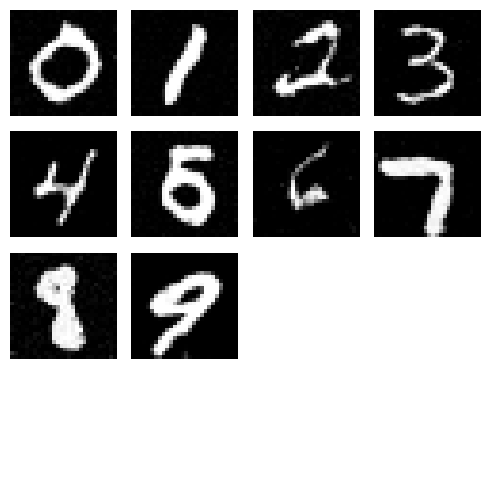

In [23]:
# Memory-efficient model loading and sampling
def load_ema_model(checkpoint_path, device='cuda'):
    """Properly load EMA model from checkpoint with memory efficiency"""
    # Create the SAME architecture as used in training
    # Based on the error, the saved model has attention=True and num_res_blocks=2
    model = DeepMiniUnetFiLM(
        base_channels=32,          # SAME as training
        condition_dim=64,          # SAME as training  
        use_morphometrics=False,   # SAME as training
        num_res_blocks=2,          # CORRECTED: Must match training (was 1, should be 2)
        use_attention=True,        # CORRECTED: Must match training (was False, should be True)
        dropout=0.1                
    ).to(device)
    
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Create EMA wrapper and load the EMA state dict
    ema = EMA(model, decay=0.999, device=device)
    ema.load_state_dict(checkpoint['ema_state_dict'])
    
    # Return the EMA model
    return ema.module.to(device)

# Clear memory before loading
clear_memory()

try:
    # Try to load the latest checkpoint
    sampling_model = load_ema_model('morpho_ckpt_5.pth', device=device)
    sampling_model.eval()
    rf = RectifiedFlow()
    
    print("Model loaded successfully!")
    get_memory_info()
    
    # Generate a small batch of samples to test
    with torch.no_grad():
        samples = sample(
            sampling_model,
            rf,
            num_samples=10,  # Start with small number
            cfg_scale=1.5,  # Lower guidance scale
            y=torch.tensor(torch.arange(0,10,1)),  # Mixed digits
            morpho=None,
            num_steps=25,   # Fewer steps for memory efficiency
            device=device
        )
        
    print("Sample generation successful!")
    visualize_samples(samples, num_display=10, figsize=(5, 5))
    
except FileNotFoundError:
    print("No checkpoint found yet. Please run training first.")
except RuntimeError as e:
    if "out of memory" in str(e):
        print("OOM during sampling. Try reducing num_samples or num_steps.")
        clear_memory()
    else:
        print(f"Error loading model: {e}")
        print("\nTip: The model architecture must match exactly what was used during training.")
        print("Check the training configuration in cell 14 for the correct parameters.")
        raise e